# Hohmann Transfer Orbit (Numba)

本笔记本只实现并展示 **标准 Hohmann transfer orbit**（两体、同平面、两次瞬时脉冲）。
建模参考：Wikipedia `Hohmann transfer orbit`。

目标：从半径 `r1` 的圆轨道，经半椭圆转移轨道，到半径 `r2` 的圆轨道。

## 核心公式

设中心天体引力参数为 `mu`，转移椭圆半长轴 `a_t=(r1+r2)/2`。

- 圆轨道速度：
  - `v_c1 = sqrt(mu/r1)`
  - `v_c2 = sqrt(mu/r2)`
- 转移椭圆近地点/远地点速度（vis-viva）：
  - `v_p = sqrt(mu*(2/r1 - 1/a_t))`
  - `v_a = sqrt(mu*(2/r2 - 1/a_t))`
- 两次变轨增量：
  - `dv1 = v_p - v_c1`
  - `dv2 = v_c2 - v_a`
- 飞行时间（半椭圆）：
  - `TOF = pi*sqrt(a_t^3/mu)`

动力学传播采用 numba 加速 RK4：

- `r_dot = v`
- `v_dot = -mu*r/|r|^3`

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hohmann_transfer_numba_solver import (
    HohmannConfig,
    simulate_hohmann_numba,
    simulate_hohmann_solve_ivp_numba_rhs,
    generate_reference_orbits,
)

In [2]:
cfg = HohmannConfig(mu=3.986004418e14, r1=7000e3, r2=42164e3, dt=5.0)
out = simulate_hohmann_numba(cfg)

print('Analytic quantities:')
for k, v in out['analytic'].items():
    if 'tof' in k:
        print(f'{k:30s}: {v:12.3f} s ({v/3600:.3f} h)')
    elif 'dv' in k or 'v_' in k:
        print(f'{k:30s}: {v:12.3f} m/s')
    else:
        print(f'{k:30s}: {v:12.3f}')

print('\nNumerical consistency check:')
for k, v in out['check'].items():
    print(f'{k:30s}: {v:12.6f}')

Analytic quantities:
a_t                           : 24582000.000
v_circ_1                      :     7546.053 m/s
v_circ_2                      :     3074.666 m/s
v_peri_t                      :     9882.849 m/s
v_apo_t                       :     1640.735 m/s
dv1                           :     2336.796 m/s
dv2                           :     1433.931 m/s
dv_total                      :     3770.727 m/s
tof                           :    19178.154 s (5.327 h)

Numerical consistency check:
arrival_radius_error_m        :    -0.799630
arrival_speed_before_burn2_m_s:  1640.734942
arrival_speed_target_circular_m_s:  3074.666284


In [3]:
# Compare with solve_ivp + numba RHS (optional cross-check)
out_ivp = simulate_hohmann_solve_ivp_numba_rhs(cfg)

y_numba = out['state'][-1]
y_ivp = out_ivp['state'][-1]
err = np.linalg.norm(y_numba - y_ivp)
print('Final-state difference |numba_rk4 - solve_ivp| =', err)

Final-state difference |numba_rk4 - solve_ivp| = 5175.120589767543


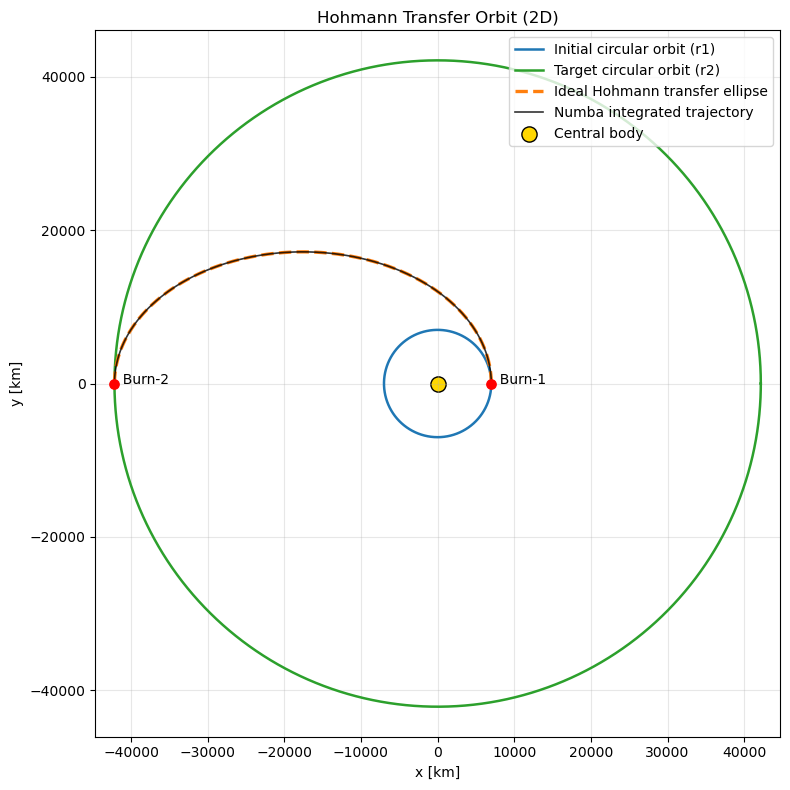

In [4]:
t = out['time']
y = out['state']
xy = y[:, :2] / 1e3  # km

_, c1, c2, tr = generate_reference_orbits(cfg)
c1 = c1 / 1e3
c2 = c2 / 1e3
tr = tr / 1e3

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(c1[:, 0], c1[:, 1], color='#1f77b4', lw=1.8, label='Initial circular orbit (r1)')
ax.plot(c2[:, 0], c2[:, 1], color='#2ca02c', lw=1.8, label='Target circular orbit (r2)')
ax.plot(tr[:, 0], tr[:, 1], color='#ff7f0e', lw=2.4, ls='--', label='Ideal Hohmann transfer ellipse')
ax.plot(xy[:, 0], xy[:, 1], color='black', lw=1.2, alpha=0.8, label='Numba integrated trajectory')

# Burns
x1, y1 = cfg.r1/1e3, 0.0
x2, y2 = -cfg.r2/1e3, 0.0
ax.scatter([x1, x2], [y1, y2], c='red', s=45, zorder=5)
ax.text(x1, y1, '  Burn-1', fontsize=10)
ax.text(x2, y2, '  Burn-2', fontsize=10)

# Central body
ax.scatter([0.0], [0.0], c='gold', s=120, edgecolors='k', label='Central body')

ax.set_title('Hohmann Transfer Orbit (2D)')
ax.set_xlabel('x [km]')
ax.set_ylabel('y [km]')
ax.axis('equal')
ax.grid(alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 参考

- Wikipedia: Hohmann transfer orbit  
  https://en.wikipedia.org/wiki/Hohmann_transfer_orbit